# Predictive Maintenance — Turbofan Engine RUL Prediction
### LSTM in PyTorch + Gradient×Input Feature Importance on NASA C-MAPSS FD001

**Pipeline:**
1. Setup
2. Data Loading
3. EDA
4. Preprocessing
5. LSTM Training
6. Feature Importance (Gradient × Input)
7. Evaluation
8. Engine Ranking + Digital Twin (Top 3)
9. Save Artifacts

## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# ── Deterministic seed — results are identical every run ──
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Data Loading

In [2]:
INDEX_COLS   = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

# ── Update this path to your local dataset ──
BASE_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'CMaps')

df_train = pd.read_csv(f'{BASE_PATH}/train_FD001.txt',
                       sep=r'\s+', header=None, names=ALL_COLS, engine='python')
df_test  = pd.read_csv(f'{BASE_PATH}/test_FD001.txt',
                       sep=r'\s+', header=None, names=ALL_COLS, engine='python')
df_rul   = pd.read_csv(f'{BASE_PATH}/RUL_FD001.txt',
                       sep=r'\s+', header=None, names=['RUL'], engine='python')

print(f'Train : {df_train.shape}')
print(f'Test  : {df_test.shape}')
print(f'RUL   : {df_rul.shape}')
print(f'Missing values — Train: {df_train.isnull().sum().sum()} | Test: {df_test.isnull().sum().sum()}')

Train : (20631, 26)
Test  : (13096, 26)
RUL   : (100, 1)
Missing values — Train: 0 | Test: 0


## 3. EDA

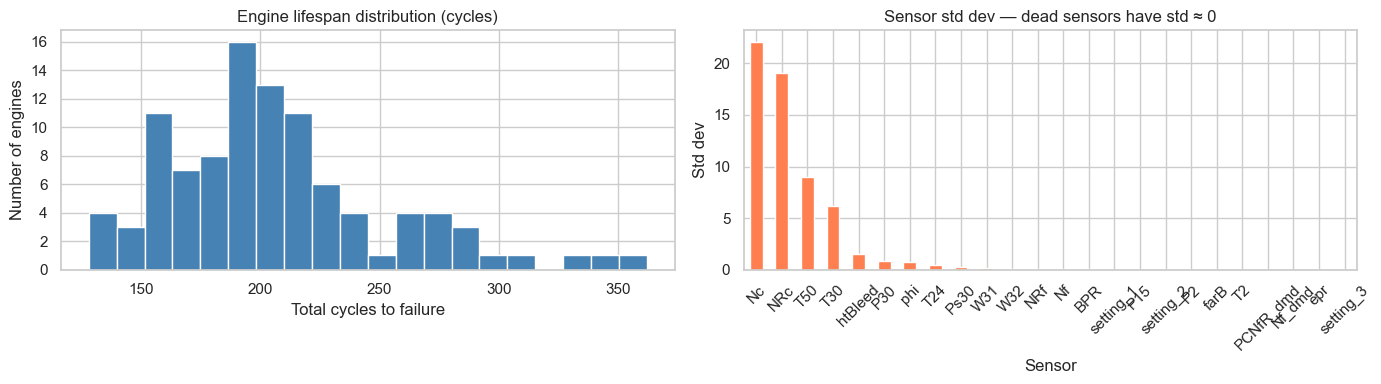

In [3]:
# ── Engine lifespan distribution + sensor variance overview ──
max_cycles = df_train.groupby('unit_number')['time_cycles'].max()
sensor_std = df_train[SENSOR_COLS + SETTING_COLS].std().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(max_cycles.values, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Engine lifespan distribution (cycles)')
axes[0].set_xlabel('Total cycles to failure')
axes[0].set_ylabel('Number of engines')
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

sensor_std.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Sensor std dev — dead sensors have std ≈ 0')
axes[1].set_xlabel('Sensor')
axes[1].set_ylabel('Std dev')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

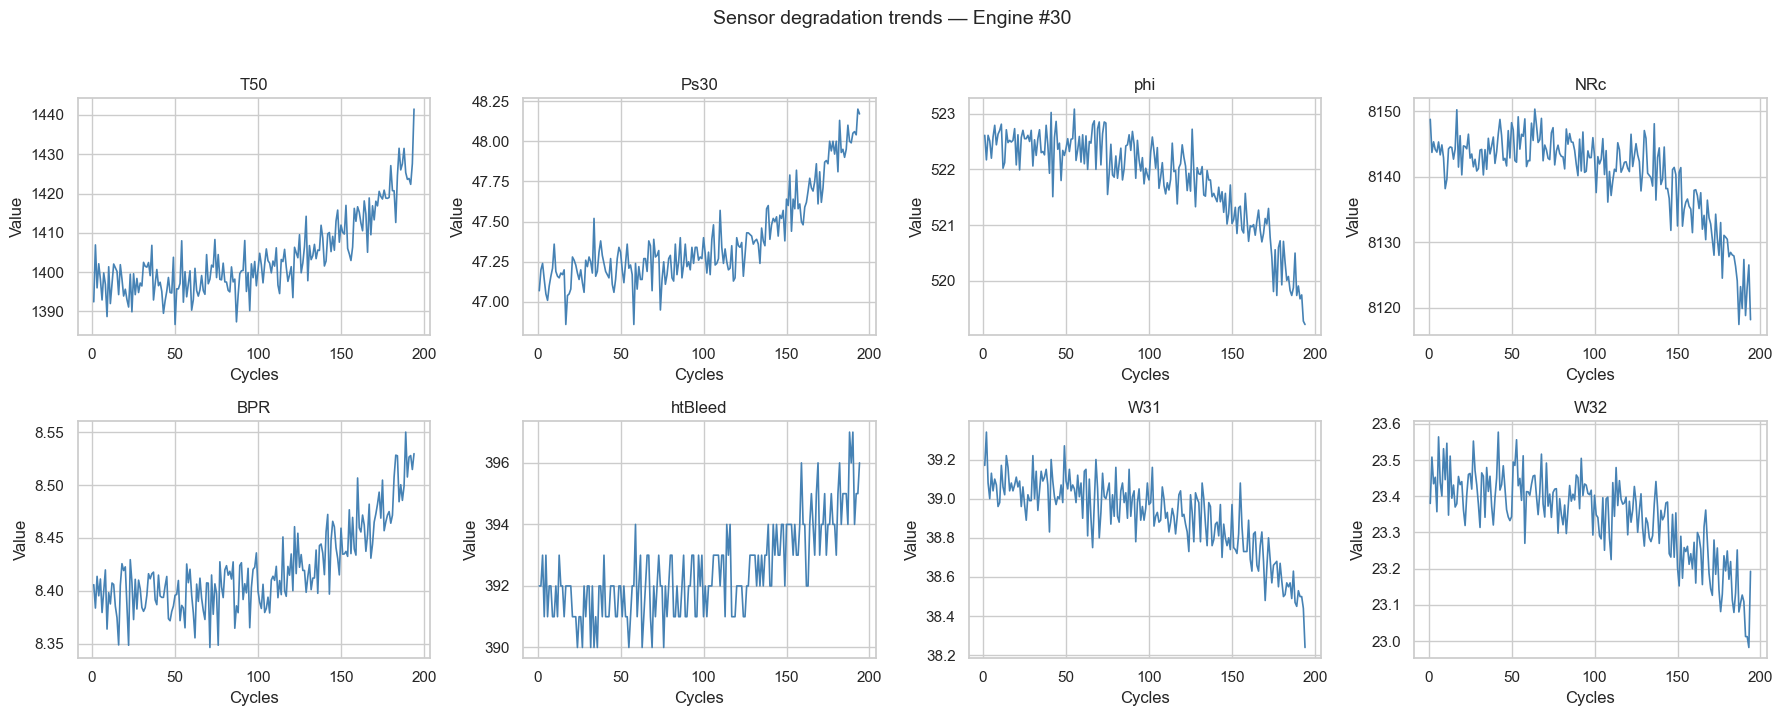

In [4]:
# ── Sensor degradation trends — single engine example ──
EXAMPLE_ENGINE = 30
engine_data  = df_train[df_train['unit_number'] == EXAMPLE_ENGINE]
PLOT_SENSORS = ['T50', 'Ps30', 'phi', 'NRc', 'BPR', 'htBleed', 'W31', 'W32']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, sensor in enumerate(PLOT_SENSORS):
    axes[i].plot(engine_data['time_cycles'], engine_data[sensor],
                 color='steelblue', linewidth=1.2)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycles')
    axes[i].set_ylabel('Value')

plt.suptitle(f'Sensor degradation trends — Engine #{EXAMPLE_ENGINE}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# ── Dead sensor removal ──
DEAD_SENSORS = [col for col in SENSOR_COLS + SETTING_COLS
                if df_train[col].nunique() == 1]
print(f'Dead sensors removed: {DEAD_SENSORS}')

FEATURE_COLS = [c for c in SENSOR_COLS + SETTING_COLS if c not in DEAD_SENSORS]
print(f'Live features: {len(FEATURE_COLS)} → {FEATURE_COLS}')

Dead sensors removed: ['T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd', 'setting_3']
Live features: 17 → ['T24', 'T30', 'T50', 'P15', 'P30', 'Nf', 'Nc', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'W31', 'W32', 'setting_1', 'setting_2']


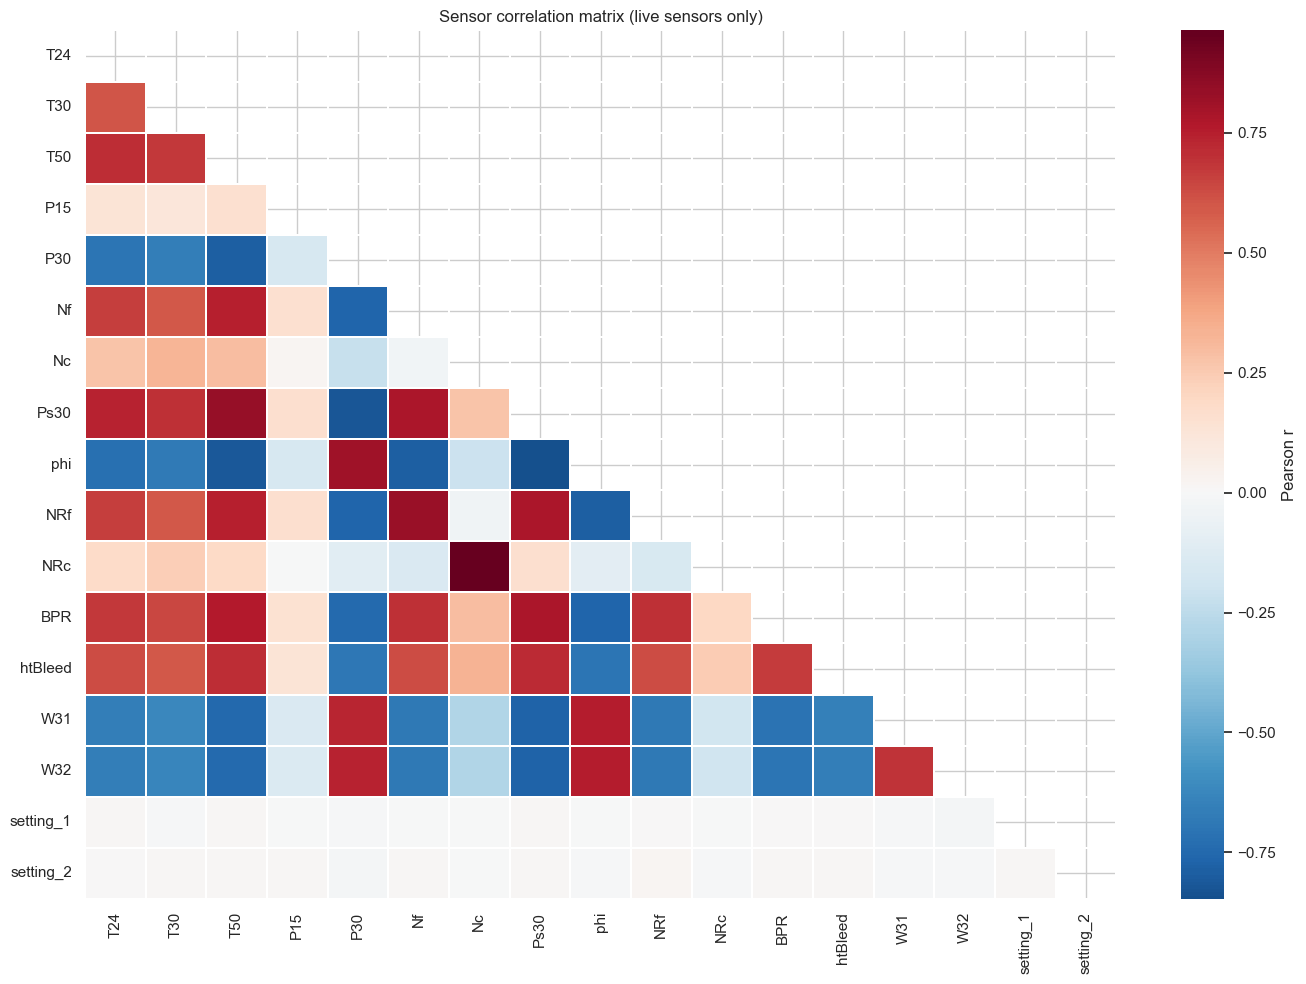

In [6]:
# ── Correlation heatmap ──
corr = df_train[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            linewidths=0.3, annot=False,
            cbar_kws={'label': 'Pearson r'})
plt.title('Sensor correlation matrix (live sensors only)')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [7]:
# RUL clipped at 125: standard practice on C-MAPSS.
# When an engine is new, knowing it has 300 vs 400 flights left is operationally irrelevant.
# Clipping focuses the model on the degradation phase that actually matters.
RUL_CLIP          = 125
SEQ_LEN           = 50
WARNING_THRESHOLD = 90

def add_rul(df, clip=RUL_CLIP):
    df = df.copy()
    max_cycle = df.groupby('unit_number')['time_cycles'].transform('max')
    df['RUL'] = (max_cycle - df['time_cycles']).clip(upper=clip)
    return df

df_train = add_rul(df_train)

last_test = df_test.groupby('unit_number')['time_cycles'].max().reset_index()
last_test.columns = ['unit_number', 'last_cycle']
df_test = df_test.merge(last_test, on='unit_number')

rul_repeated = np.repeat(
    df_rul['RUL'].values,
    df_test.groupby('unit_number').size().values
)
df_test['RUL'] = (rul_repeated + (df_test['last_cycle'] - df_test['time_cycles'])).clip(upper=RUL_CLIP)
df_test.drop(columns=['last_cycle'], inplace=True)

print(f'Train RUL range: {df_train["RUL"].min():.0f} – {df_train["RUL"].max():.0f}')
print(f'Test  RUL range: {df_test["RUL"].min():.0f} – {df_test["RUL"].max():.0f}')

Train RUL range: 0 – 125
Test  RUL range: 7 – 125


In [8]:
scaler = MinMaxScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

def build_sequences(df, feature_cols, seq_len=SEQ_LEN):
    X, y = [], []
    for _, group in df.groupby('unit_number'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        for i in range(len(data) - seq_len):
            X.append(data[i:i + seq_len])
            y.append(labels[i + seq_len - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_all, y_train = build_sequences(df_train, FEATURE_COLS)
X_test_all,  y_test  = build_sequences(df_test,  FEATURE_COLS)

val_split = int(len(X_train_all) * 0.8)
X_tr,  y_tr  = X_train_all[:val_split], y_train[:val_split]
X_val, y_val = X_train_all[val_split:], y_train[val_split:]

print(f'Train sequences : {X_tr.shape}')
print(f'Val sequences   : {X_val.shape}')
print(f'Test sequences  : {X_test_all.shape}')

Train sequences : (12504, 50, 17)
Val sequences   : (3127, 50, 17)
Test sequences  : (8162, 50, 17)


In [9]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE   = 128
train_loader = DataLoader(RULDataset(X_tr, y_tr),         batch_size=BATCH_SIZE, shuffle=True,
                          worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(RULDataset(X_val, y_val),       batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(RULDataset(X_test_all, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 5. LSTM Model (PyTorch)

In [10]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3, patience=10):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()

    best_val_loss    = float('inf')
    patience_counter = 0
    history = {'train': [], 'val': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(Xb)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(Xb), yb).item() * len(Xb)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)
        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{epochs} — Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_lstm.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

    model.load_state_dict(torch.load('best_lstm.pt', weights_only=True))
    return model, history


def evaluate_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.append(model(Xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()
    rmse  = np.sqrt(mean_squared_error(trues, preds))
    return preds, trues, rmse

In [11]:
print('=== Training LSTM ===')
model = LSTMRegressor(input_size=len(FEATURE_COLS))
model, history = train_model(model, train_loader, val_loader, epochs=100, patience=10)

preds, trues, rmse = evaluate_model(model, test_loader)
print(f'\nTest RMSE: {rmse:.4f}')

=== Training LSTM ===
Epoch  10/100 — Train MSE: 213.7729 | Val MSE: 148.2780
Epoch  20/100 — Train MSE: 161.9073 | Val MSE: 155.2263
Early stopping at epoch 24

Test RMSE: 12.8180


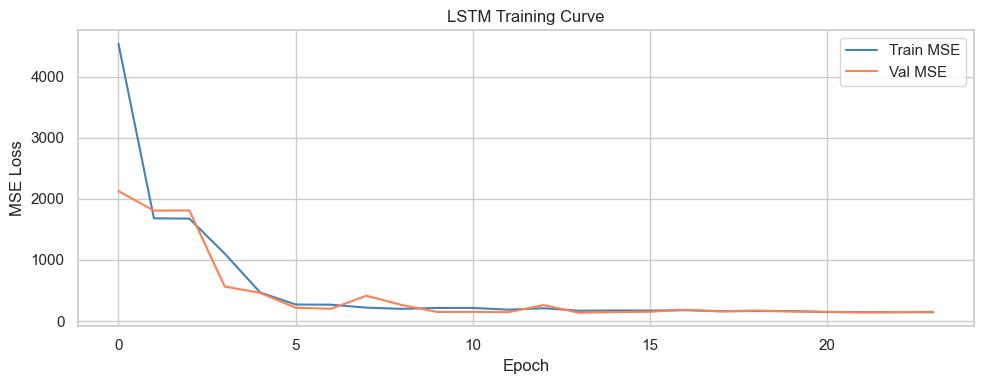

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train MSE', color='steelblue')
plt.plot(history['val'],   label='Val MSE',   color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance (Gradient × Input)

In [13]:
model.eval()
model.cpu()

np.random.seed(SEED)
explain_idx = np.random.choice(len(X_test_all), size=200, replace=False)
X_explain_t = torch.tensor(X_test_all[explain_idx], requires_grad=True)

output = model(X_explain_t)
output.sum().backward()

grads        = X_explain_t.grad.detach().numpy()
inputs       = X_test_all[explain_idx]
grad_x_input = np.abs(grads * inputs)
mean_imp     = grad_x_input.mean(axis=(0, 1))

imp_df = pd.DataFrame({
    'sensor':     FEATURE_COLS,
    'importance': mean_imp
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(imp_df.to_string(index=False))
model.to(DEVICE)

   sensor  importance
      P30    1.613282
      phi    1.484567
      W31    1.269957
      W32    1.167338
      T50    1.059103
     Ps30    1.018409
      BPR    0.973757
      T24    0.919411
  htBleed    0.842205
      NRc    0.799878
       Nf    0.719833
       Nc    0.711597
      NRf    0.703008
      P15    0.455509
      T30    0.336697
setting_1    0.241547
setting_2    0.092862


LSTMRegressor(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

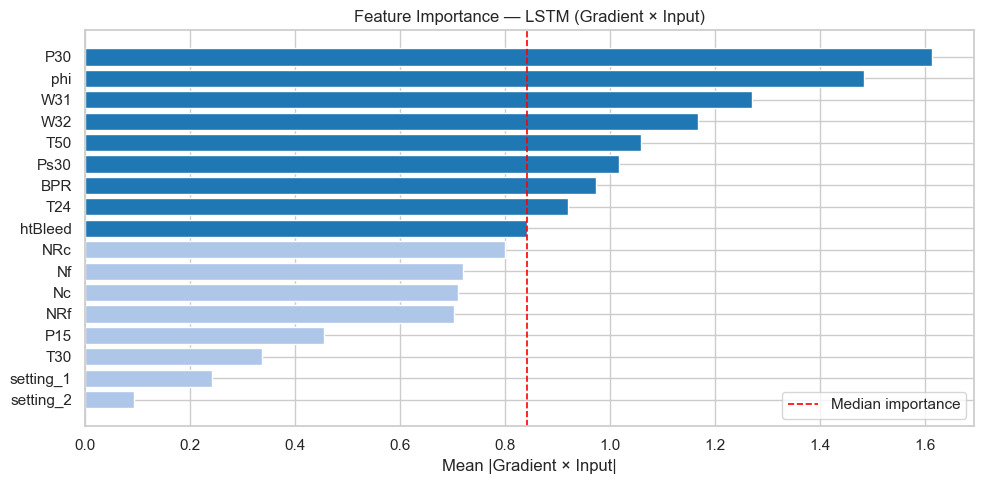

In [14]:
plt.figure(figsize=(10, 5))
colors = ['#1f77b4' if v >= imp_df['importance'].median() else '#aec7e8'
          for v in imp_df['importance']]
plt.barh(imp_df['sensor'][::-1], imp_df['importance'][::-1], color=colors[::-1])
plt.axvline(imp_df['importance'].median(), color='red', linestyle='--',
            linewidth=1.2, label='Median importance')
plt.xlabel('Mean |Gradient × Input|')
plt.title('Feature Importance — LSTM (Gradient × Input)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Evaluation

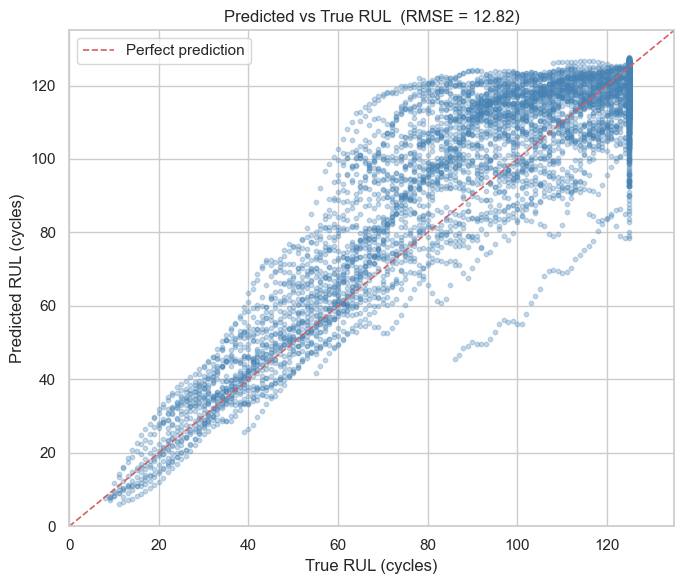

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(trues, preds, alpha=0.3, s=10, color='steelblue')
lims = [0, RUL_CLIP + 10]
plt.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('True RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'Predicted vs True RUL  (RMSE = {rmse:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

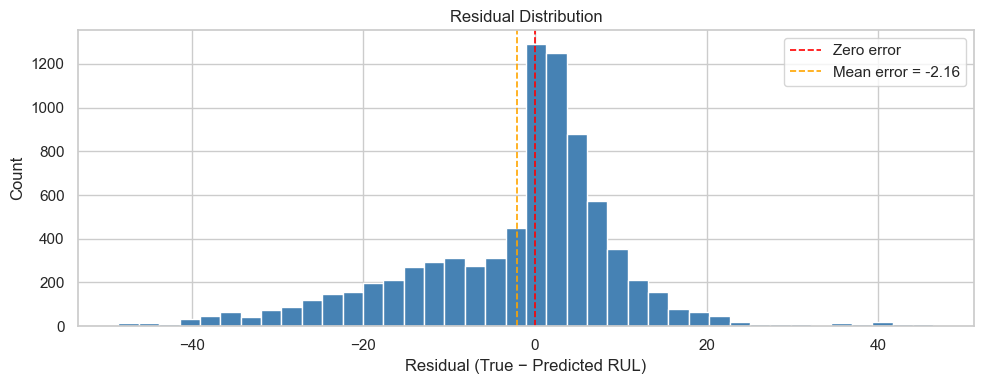

In [16]:
residuals = trues - preds

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=40, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero error')
plt.axvline(residuals.mean(), color='orange', linestyle='--',
            linewidth=1.2, label=f'Mean error = {residuals.mean():.2f}')
plt.xlabel('Residual (True − Predicted RUL)')
plt.ylabel('Count')
plt.title('Residual Distribution')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Engine Ranking + Digital Twin (Top 3)

In [17]:
# ── Rank all engines by lead time ──
results = []
for uid in range(1, 101):
    engine = df_test[df_test['unit_number'] == uid]
    n      = len(engine)
    if n <= SEQ_LEN:
        continue

    data   = engine[FEATURE_COLS].values.astype(np.float32)
    cycles = engine['time_cycles'].values
    seqs   = np.array([data[i:i + SEQ_LEN] for i in range(n - SEQ_LEN)])
    X_eng  = torch.tensor(seqs).to(DEVICE)

    model.eval()
    with torch.no_grad():
        preds_eng = model(X_eng).cpu().numpy().flatten()

    preds_full    = np.concatenate([np.full(SEQ_LEN, preds_eng[0]), preds_eng])[:n]
    warning_cycle = next(
        (cycles[i] for i in range(len(preds_full)) if preds_full[i] <= WARNING_THRESHOLD),
        None
    )

    lead_time = int(cycles[-1] - warning_cycle) if warning_cycle is not None else 0
    results.append({'engine': uid, 'lead_time': lead_time,
                    'failure_cycle': int(cycles[-1]),
                    'alert_cycle': int(warning_cycle) if warning_cycle is not None else None})

results_df = pd.DataFrame(results).sort_values('lead_time', ascending=False)
print('Top 10 engines by lead time:')
print(results_df.head(10).to_string(index=False))

Top 10 engines by lead time:
 engine  lead_time  failure_cycle  alert_cycle
     49         90            303        213.0
     81         89            213        124.0
     76         78            205        127.0
     31         75            196        121.0
     68         69            187        118.0
     42         69            156         87.0
     91         64            234        170.0
     35         63            198        135.0
     34         61            203        142.0
     82         59            162        103.0


Top 3 engines: [49, 81, 76]



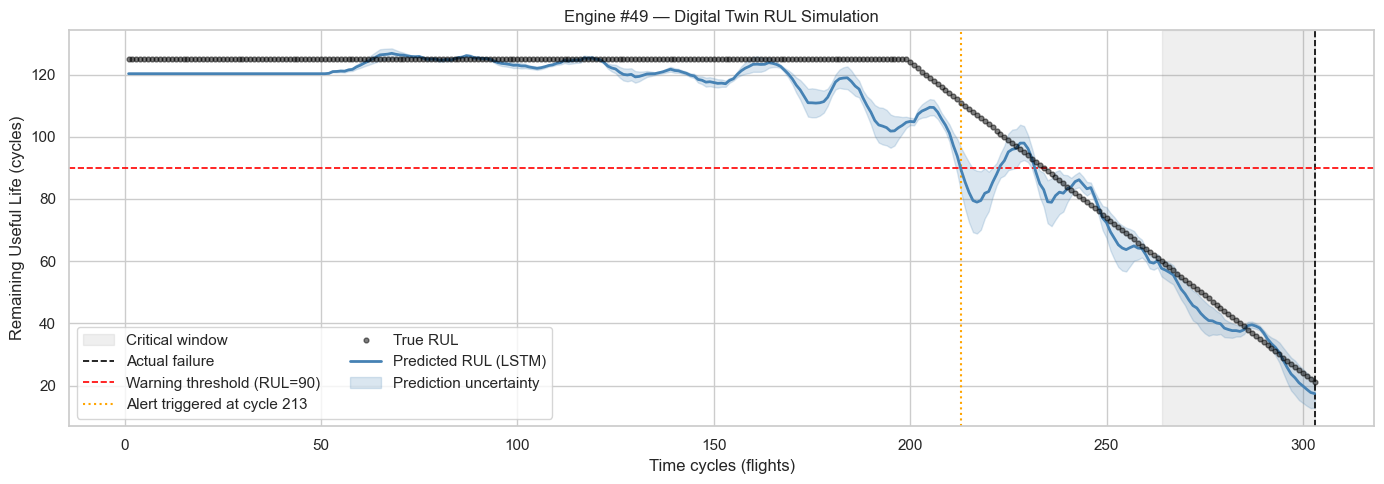

Engine #49: alert at cycle 213, failure at cycle 303 → 90 cycles (15–22 days) lead time


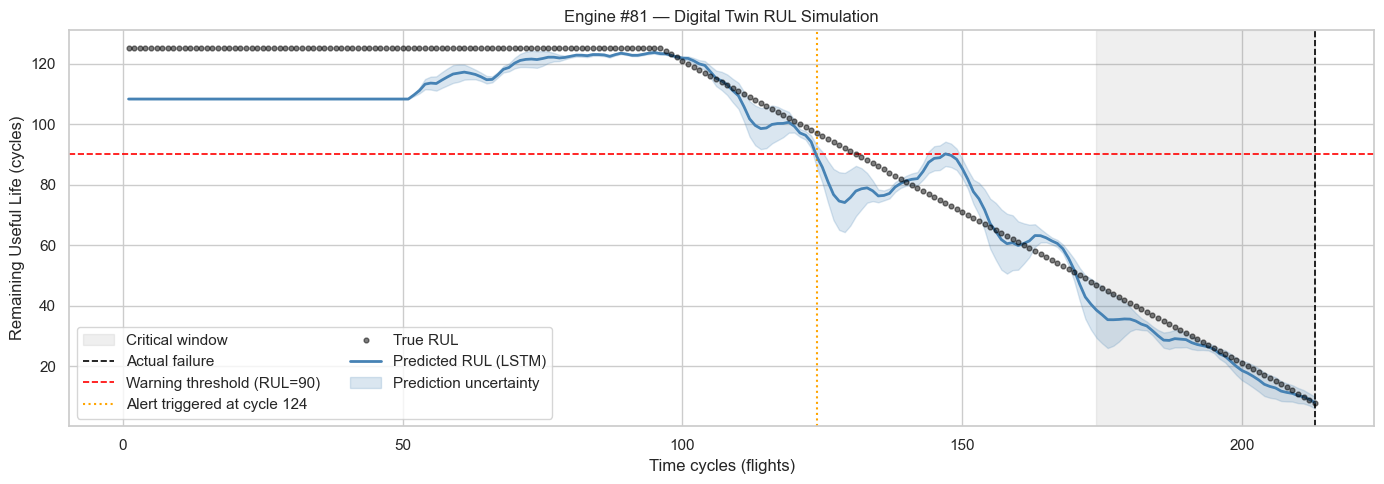

Engine #81: alert at cycle 124, failure at cycle 213 → 89 cycles (14–22 days) lead time


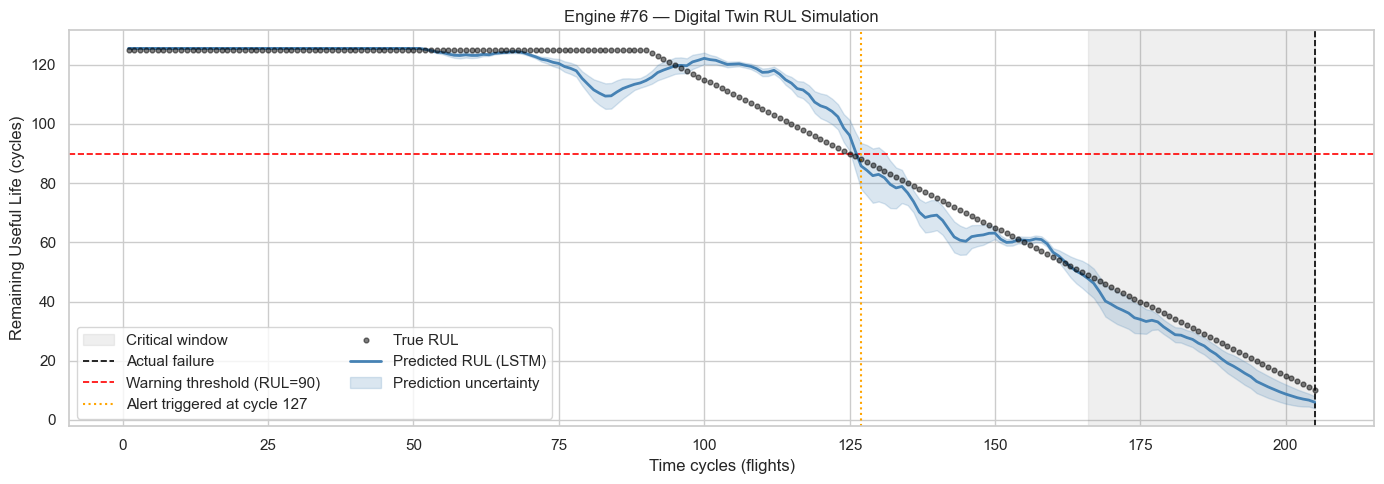

Engine #76: alert at cycle 127, failure at cycle 205 → 78 cycles (13–19 days) lead time


In [18]:
# ── Digital Twin — top 3 engines ──
def simulate_engine(unit_id, warning_threshold=WARNING_THRESHOLD):
    engine = df_test[df_test['unit_number'] == unit_id].copy()
    n      = len(engine)
    if n <= SEQ_LEN:
        print(f'Engine {unit_id}: not enough cycles.')
        return

    data     = engine[FEATURE_COLS].values.astype(np.float32)
    true_rul = engine['RUL'].values
    cycles   = engine['time_cycles'].values

    seqs  = np.array([data[i:i + SEQ_LEN] for i in range(n - SEQ_LEN)])
    X_eng = torch.tensor(seqs).to(DEVICE)

    model.eval()
    with torch.no_grad():
        preds_eng = model(X_eng).cpu().numpy().flatten()

    preds_full = np.concatenate([np.full(SEQ_LEN, preds_eng[0]), preds_eng])[:n]
    pred_std   = pd.Series(preds_full).rolling(window=10, min_periods=1).std().fillna(0).values

    warning_cycle = next(
        (cycles[i] for i in range(len(preds_full)) if preds_full[i] <= warning_threshold),
        None
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    critical_start = cycles[max(0, len(cycles) - 40)]
    ax.axvspan(critical_start, cycles[-1], color='grey', alpha=0.12, label='Critical window')
    ax.axvline(cycles[-1], color='black', linestyle='--', linewidth=1.2, label='Actual failure')
    ax.axhline(warning_threshold, color='red', linestyle='--', linewidth=1.2,
               label=f'Warning threshold (RUL={warning_threshold})')

    if warning_cycle is not None:
        ax.axvline(warning_cycle, color='orange', linestyle=':', linewidth=1.5,
                   label=f'Alert triggered at cycle {warning_cycle}')

    ax.scatter(cycles, true_rul, color='black', s=12, alpha=0.5, label='True RUL', zorder=3)
    ax.plot(cycles, preds_full, color='steelblue', linewidth=2, label='Predicted RUL (LSTM)')
    ax.fill_between(cycles, preds_full - pred_std, preds_full + pred_std,
                    color='steelblue', alpha=0.2, label='Prediction uncertainty')

    ax.set_xlabel('Time cycles (flights)')
    ax.set_ylabel('Remaining Useful Life (cycles)')
    ax.set_title(f'Engine #{unit_id} — Digital Twin RUL Simulation')
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    if warning_cycle is not None:
        lead_time = int(cycles[-1] - warning_cycle)
        print(f'Engine #{unit_id}: alert at cycle {warning_cycle}, '
              f'failure at cycle {cycles[-1]} → {lead_time} cycles ({lead_time // 6}–{lead_time // 4} days) lead time')
    else:
        print(f'Engine #{unit_id}: prediction never crossed threshold')


top3 = results_df[results_df['lead_time'] > 0].head(3)['engine'].tolist()
print(f'Top 3 engines: {top3}\n')
for uid in top3:
    simulate_engine(uid)

## 9. Save Artifacts

In [19]:
os.chdir(os.path.dirname(os.path.abspath('__file__')))
torch.save(model.state_dict(), 'lstm_final.pt')
joblib.dump(scaler,       'scaler_final.pkl')
joblib.dump(FEATURE_COLS, 'feature_list.pkl')
joblib.dump(imp_df,       'feature_importance.pkl')
results_df.to_csv('engine_ranking.csv', index=False)

print('Saved:')
print('  lstm_final.pt          — model weights')
print('  scaler_final.pkl       — MinMaxScaler')
print('  feature_list.pkl       — feature names')
print('  feature_importance.pkl — gradient x input importance')
print('  engine_ranking.csv     — lead time ranking all engines')
print(f'\nFinal RMSE        : {rmse:.4f}')
print(f'SEQ_LEN           : {SEQ_LEN}')
print(f'RUL_CLIP          : {RUL_CLIP} (standard C-MAPSS practice)')
print(f'Warning threshold : {WARNING_THRESHOLD} cycles')

Saved:
  lstm_final.pt          — model weights
  scaler_final.pkl       — MinMaxScaler
  feature_list.pkl       — feature names
  feature_importance.pkl — gradient x input importance
  engine_ranking.csv     — lead time ranking all engines

Final RMSE        : 12.8180
SEQ_LEN           : 50
RUL_CLIP          : 125 (standard C-MAPSS practice)
Warning threshold : 90 cycles
